<a href="https://colab.research.google.com/github/sbajnaid/Lab-6/blob/main/ML_Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("/content/[Lab 6] Ecommerce Customers.csv")

In [3]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


All data types are appropriat for their corresponding features, and all the features have the complete number of records.

In [5]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [6]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

This function shows us all of the features in the dataset. They are Email, Address, Avatar, Average Session Length, Time on App, Time on Website, Length of Membership, and Yearly Amount Spent.

In [37]:
print(df.isna().sum())

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


No missing values.

In [38]:
df.duplicated()[df.duplicated()==True]

,0


No duplicate rows.

In [40]:
print("Shape (rows, columns): ", df.shape,"\n")

Shape (rows, columns):  (500, 8) 



In [51]:
#checking for minimum value in Avg. Session Length
df['Avg. Session Length'].min()

29.532428967057943

In [52]:
#checking for minimum value in Time on App
df['Time on App'].min()

8.508152176032603

In [53]:
#checking for minimum value in Time on Website
df['Time on Website'].min()

33.91384724758464

In [54]:
#checking for minimum value in Length of Membership
df['Length of Membership'].min()

0.2699010899842742

In [55]:
#checking for minimum value in Yearly Amount Spent
df['Yearly Amount Spent'].min()

256.67058229005585

No negative values in any of the features.

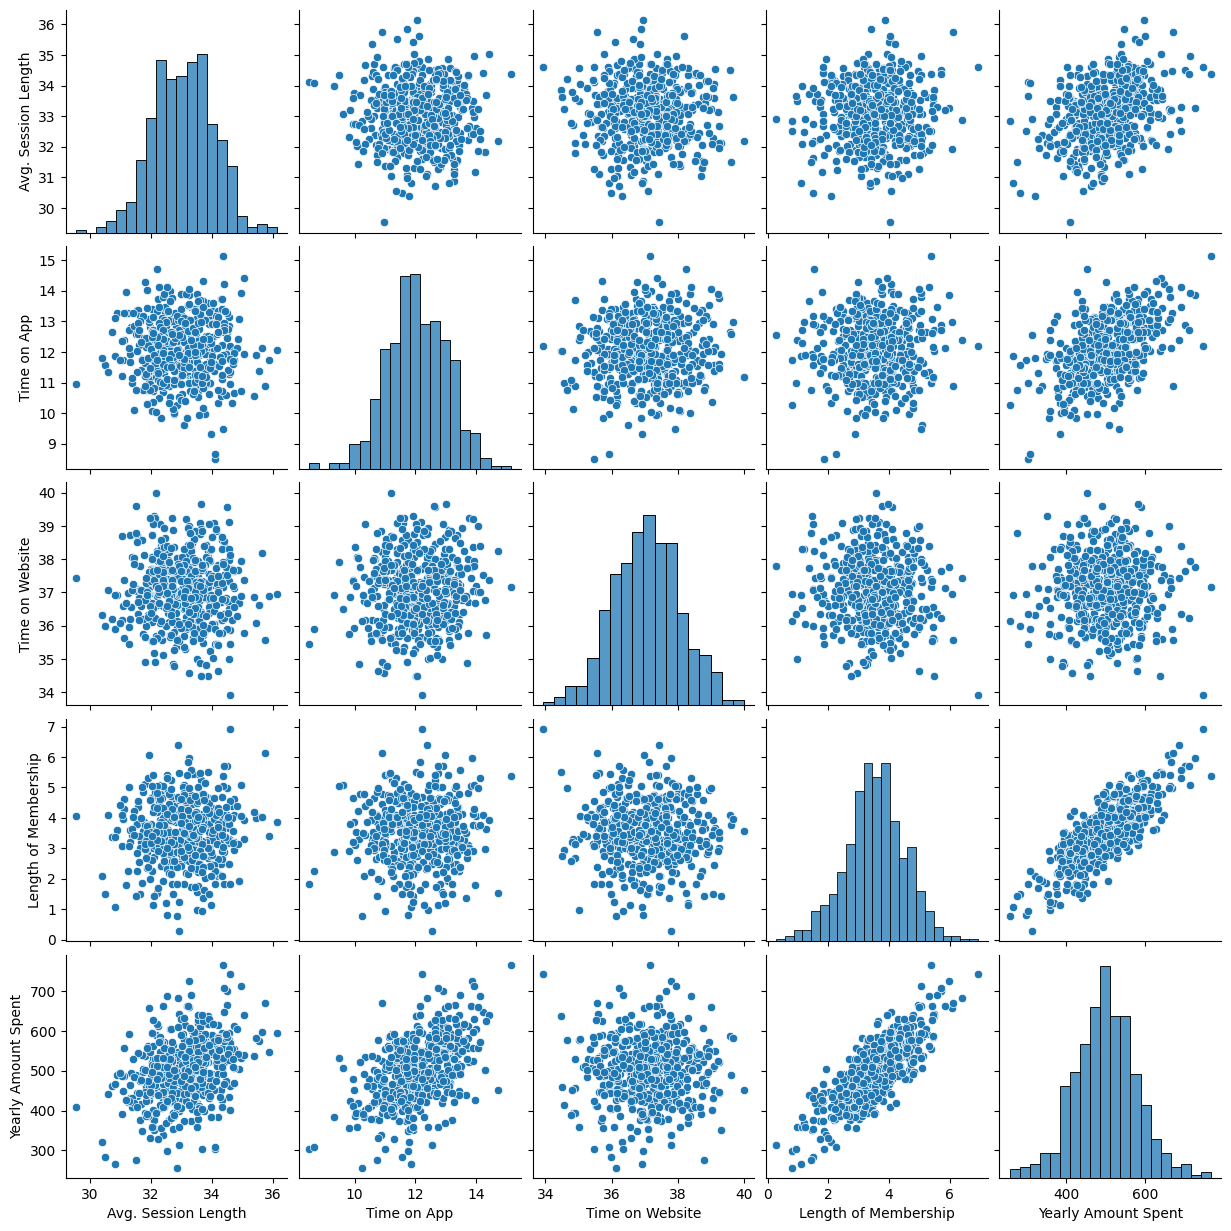

In [7]:
sns.pairplot(df)

EDA part 1.

Mostly normal distributions.

/tmp/ipykernel_13844/429359120.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Yearly Amount Spent'])


<Axes: xlabel='Yearly Amount Spent', ylabel='Density'>

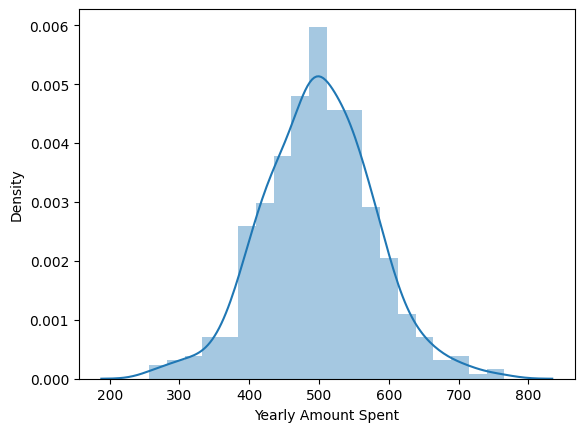

In [8]:
sns.distplot(df['Yearly Amount Spent'])

EDA part 2.

In [19]:
#selecting the columns with numerical values only
selected_cols = df[['Avg. Session Length', 'Time on App',  'Time on Website',  'Length of Membership', 'Yearly Amount Spent']]

<Axes: >

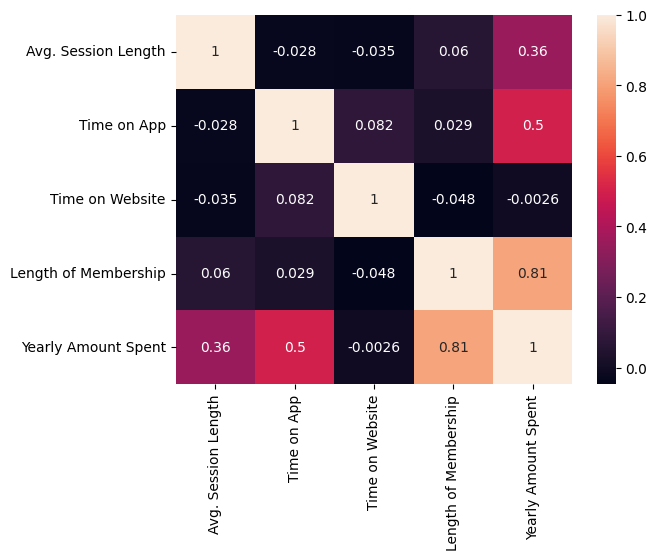

In [18]:
sns.heatmap(selected_cols.corr(), annot=True)

EDA part 3. Heatmap shows low correlations between most of the features.

In [66]:
#removing Email, Address, and Avatar because they are not useful
drop_cols = [ "Email", "Address", "Avatar"]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + ['Yearly Amount Spent'])
y = df['Yearly Amount Spent'] #target variable

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 4)
y shape: (500,)


Choosing Yearly Amount Spent as the target variable. Excluding Email, Address, and Avatar because they are not relevant.

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

Splitting the data into training and testing.

In [68]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

Choosing a linear regression model to train the data.

In [71]:
# print the intercept
print(lm.intercept_)

-1045.1152168245746


In [26]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,7.866632e-15
Time on App,-1.554312e-15
Time on Website,2.027729e-15
Length of Membership,5.887868e-15
Yearly Amount Spent,1.000000e+00


In [72]:
#testing how well the model works
predictions = lm.predict(X_test)

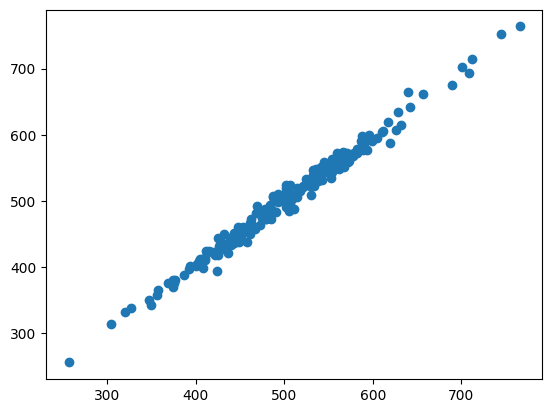

In [73]:
plt.scatter(y_test,predictions)

Scatter plot shows a positive correlation.

/tmp/ipykernel_13844/4225196828.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-predictions),bins=10);


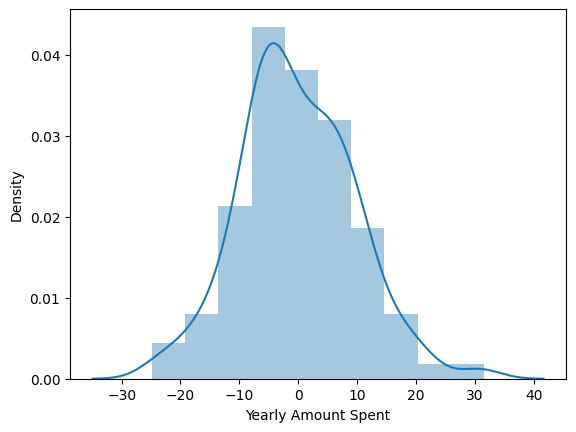

In [74]:
sns.distplot((y_test-predictions),bins=10);

Histogram shows monetary values in the negatives, which is illogical.

In [75]:
#comparing regression evaluation metrics MAE, MSE, and RMSE
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.74267128583874
MSE: 93.83297800820075
RMSE: 9.68674238370159


Results of evaluation metrics.
MAE: on average, the model’s predictions deviate from the actual values by approximately 7.74 units.
MSE: the average of the squared prediction errors is 93.83, so the model produces a significant amount of error.
RMSE: the model’s predictions typically differ from the actual values by about 9.69 units.

In [76]:
lm.fit

<bound method LinearRegression.fit of LinearRegression()>